In [55]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

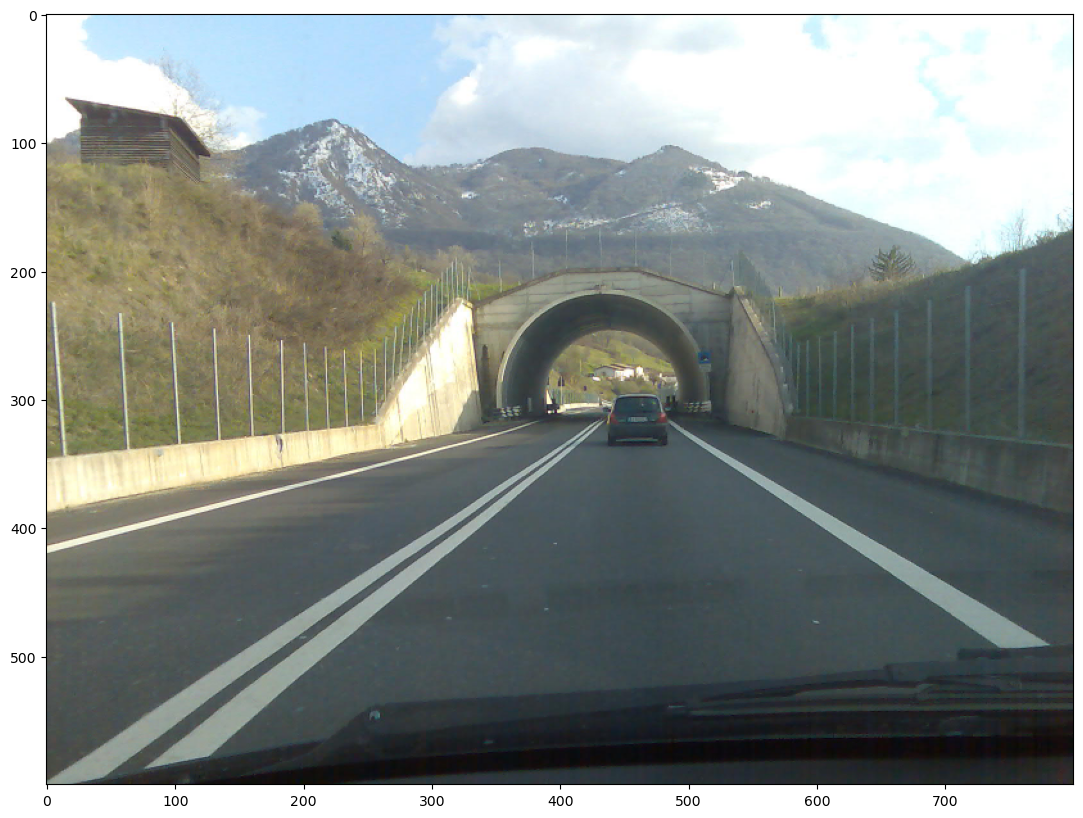

In [75]:
img = cv2.imread('Downloads/dashcam.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
plt.imshow(img)

In [76]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

In [79]:
edges = cv2.Canny(gray, threshold1=100, threshold2=150)
edges[0:300] = 0


(<Axes: title={'center': 'Hough lines'}>,
 Text(0.5, 1.0, 'Hough lines'))

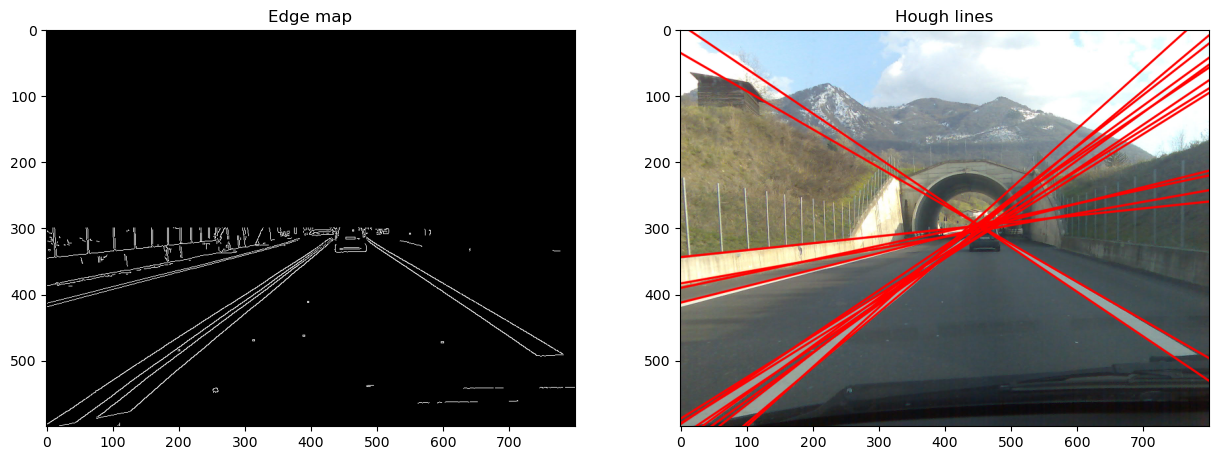

In [80]:
lines = cv2.HoughLines(edges, rho=2, theta=2*np.pi/180, threshold=190)
result = np.copy(img)
if lines is not None:
    lines = lines[:, 0, :]  

    for rho, theta in lines:
        a = math.cos(theta)
        b = math.sin(theta)

        x0 = a * rho
        y0 = b * rho

        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))

        cv2.line(result, pt1, pt2, (255, 0, 0), 2, cv2.LINE_AA)
plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Hough lines')    

In [90]:
filtered_lines = []
for line in lines:
    theta = line[1] 
    theta_deg = theta * 180 / np.pi
    print(theta_deg)
    if abs(theta - np.pi/2) > (20 * np.pi/180):
       filtered_lines.append(line)

50.0
76.0
53.999996
51.999996
123.99999
84.0
120.0
55.999996
53.999996
57.999996
80.0
78.0
55.999996
57.999996
48.0


(<Axes: title={'center': 'Hough lines'}>,
 Text(0.5, 1.0, 'Hough lines'))

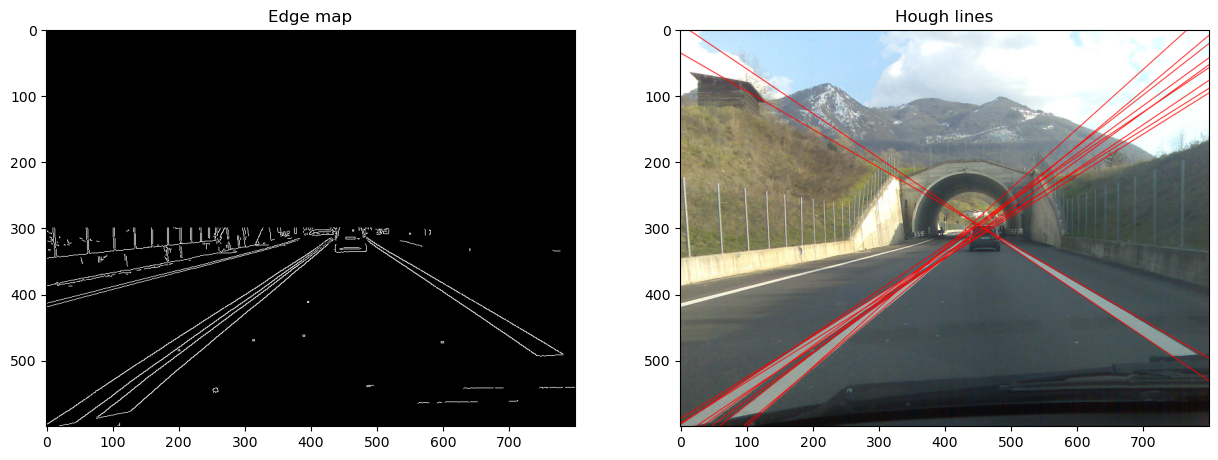

In [91]:
result = np.copy(img)

for line in filtered_lines:
    rho = line[0]     
    theta = line[1]   

    a = math.cos(theta)
    b = math.sin(theta)
    x0 = a * rho
    y0 = b * rho

    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))

    cv2.line(result, pt1, pt2, 255, 1, cv2.LINE_AA)
plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Hough lines')

In [92]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6).fit(filtered_lines)
kmeans.cluster_centers_

C:\Users\User\anaconda3\envs\cv\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([[ 31.        ,   2.09439516],
       [511.5       ,   0.91629785],
       [ -7.        ,   2.16420817],
       [497.        ,   0.99483767],
       [521.        ,   0.87266463],
       [505.        ,   0.97738436]])

(<Axes: title={'center': 'Hough lines'}>,
 Text(0.5, 1.0, 'Hough lines'))

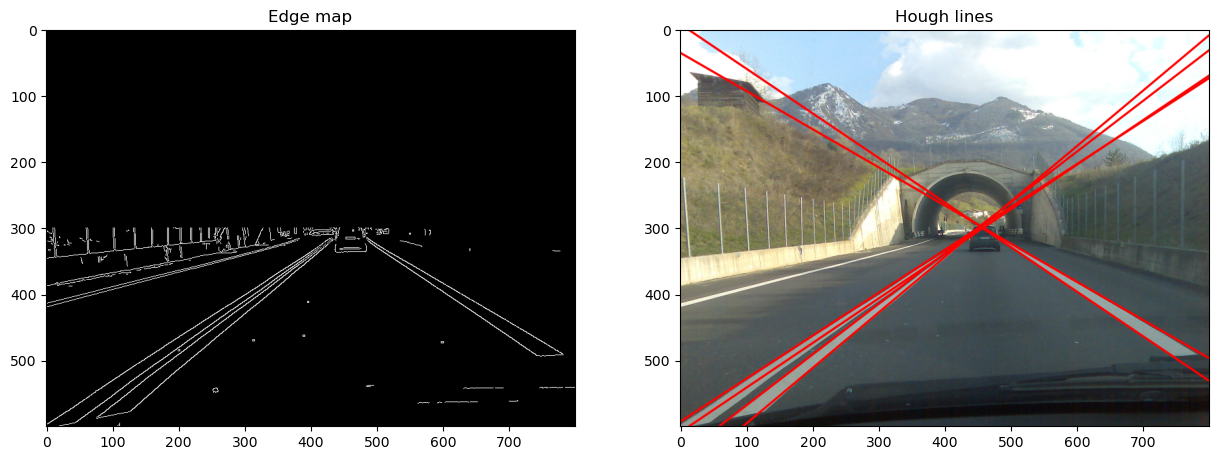

In [93]:
result = np.copy(img)
for line in kmeans.cluster_centers_:
    rho = line[0]
    theta = line[1]

    a = math.cos(theta)
    b = math.sin(theta)

    x0 = a * rho
    y0 = b * rho

    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))

    cv2.line(result, pt1, pt2, 255, 2, cv2.LINE_AA)
plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Hough lines')